Evaluación de Fuentes de Datos Geoespaciales: Cobertura Vegetal.


El objetivo es determinar qué dataset de Land Cover es más adecuado para alimentar el Autómata Celular Híbrido de incendios forestales.

Evaluación de Fuentes de Datos Geoespaciales: Cobertura Vegetal
El objetivo es determinar qué dataset de Land Cover es más adecuado para alimentar el Autómata Celular Híbrido de incendios forestales.

**1. MODIS Land Cover (MCD12Q1 - NASA)**

Resolución: 500 metros por píxel.

Formato y Acceso: Formato HDF4, requiere reproyección (por defecto usa proyección sinusoidal). Se obtiene vía NASA Earthdata.

Ventaja: Posee un registro histórico continuo desde 2001, útil si el caso de estudio es un incendio muy antiguo.

Desventaja: Su baja resolución agrupa 25 hectáreas en un solo píxel, perdiendo detalles topográficos cruciales (ríos, carreteras) que actúan como barreras para el fuego.

**2. ESA WorldCover (v200 - 2021)**

Resolución: 10 metros por píxel.

Formato y Acceso: Formato GeoTIFF Cloud-Optimized, directamente compatible con librerías estándar como rasterio.

Ventaja: Nivel de detalle ultra alto, ideal para modelar propagación de fuego a escala táctica/local.

Desventaja: Solo tiene versiones para 2020 y 2021, aunque los tipos de ecosistemas principales en la Amazonía no varían drásticamente en un par de años.

**ESA WorldCover es la opción superior para este modelo. La resolución de 10 m frente a los 500 m de MODIS es el factor decisivo, ya que el autómata necesita una grilla fina para simular frentes de fuego realistas.**

In [ ]:
 import rasterio
 import numpy as np
 import matplotlib.pyplot as plt

In [ ]:
ruta_mapa = "/ESA_WorldCover_10m_2021_v200_S09W075_Map.tif"
with rasterio.open(ruta_mapa) as dataset:
  print("Datos del mapa de Pucallpa")
  print("Ancho (columnas): ",dataset.width)
  print("Alto(filas): ",dataset.height )
  print("Sistema de coordenadas: ",dataset.crs)
  print("Cantidad de capas (bandas): ",dataset.count)

Datos del mapa de Pucallpa
Ancho (columnas):  36000
Alto(filas):  36000
Sistema de coordenadas:  EPSG:4326
Cantidad de capas (bandas):  1


La matriz se redujo a alto:  720  y ancho:  720
Valores únicos (Categorías ESA) encontrados en el mapa: [10 20 30 40 50 60 80 90]


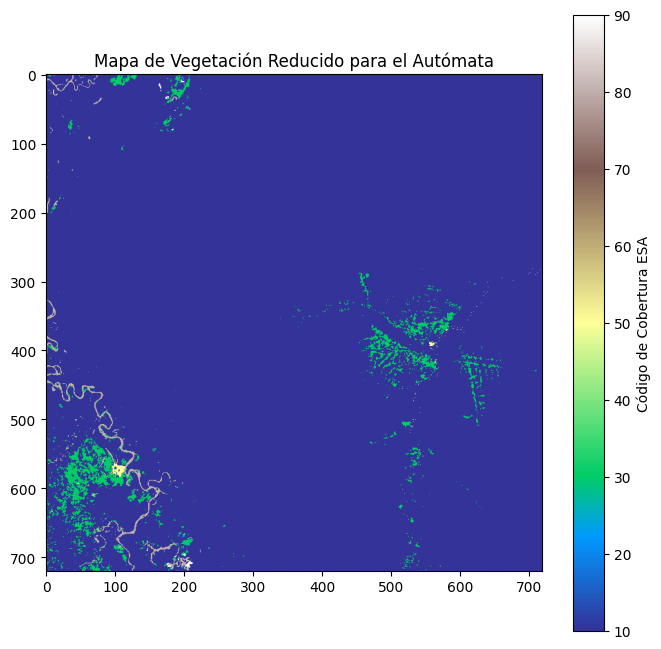

In [ ]:
import rasterio
# Importamos la herramienta específica para remuestrear
from rasterio.enums import Resampling
with rasterio.open(ruta_mapa) as dataset:
  # 2. Definimos cuánto queremos achicar el mapa.
    # Usaremos 0.02 (2%) para pasarlo de 36,000 a unos 720 píxeles.
  factor = 0.02
  nuevo_alto=int(dataset.height * factor)
  nuevo_ancho = int (dataset.width * factor)
  print ("La matriz se redujo a alto: ",nuevo_alto," y ancho: ",nuevo_ancho)
  matriz_vegetacion=dataset.read(
      out_shape = (nuevo_alto,nuevo_ancho),
      resampling = Resampling.mode
  )
  print("Valores únicos (Categorías ESA) encontrados en el mapa:", np.unique(matriz_vegetacion))
plt.figure(figsize=(8, 8))
plt.imshow(matriz_vegetacion[0], cmap='terrain')
plt.title("Mapa de Vegetación Reducido para el Autómata")
plt.colorbar(label="Código de Cobertura ESA")
plt.show()

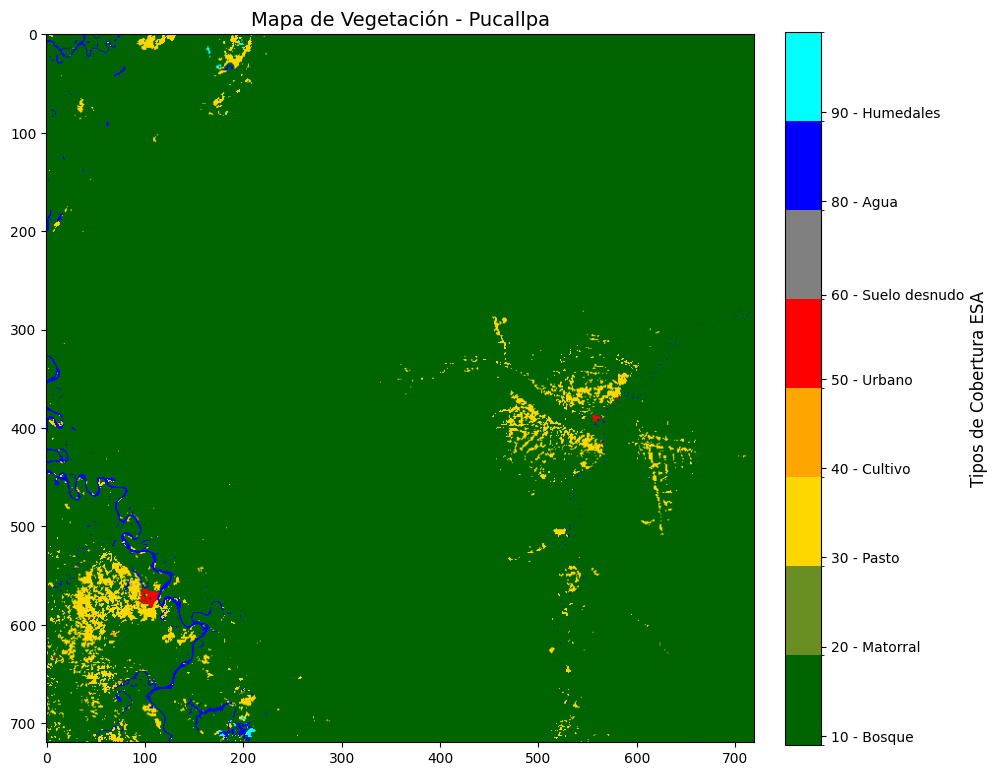

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# 1. Definimos los colores exactos para cada número de la ESA
# 10=Verde oscuro (Bosque), 20=Verde claro (Matorral), 30=Amarillo (Pasto)
# 40=Naranja (Cultivo), 50=Rojo (Urbano), 60=Gris (Suelo desnudo)
# 80=Azul (Agua), 90=Celeste (Humedal)
colores_esa = ['darkgreen', 'olivedrab', 'gold', 'orange', 'red', 'gray', 'blue', 'cyan']

# paleta perzonalizada de colores
cmap_piola = mcolors.ListedColormap(colores_esa)

#  rangos de números corresponden a cada color
# (ej. del 9 al 19 se pinta con el primer color, que es verde oscuro para el código 10)
limites = [9, 19, 29, 39, 49, 59, 79, 89, 99]
norm = mcolors.BoundaryNorm(limites, cmap_piola.N)

# . Dibujamos el lienzo
plt.figure(figsize=(10, 10))

# Aplicamos nuestro cmap_piola y la norma de límites al mapa
imagen = plt.imshow(matriz_vegetacion[0], cmap=cmap_piola, norm=norm)

plt.title("Mapa de Vegetación - Pucallpa", fontsize=14)

# LEYENDA DE COMO SE CLASIFICA EL ESA
barra = plt.colorbar(imagen, ticks=[10, 20, 30, 40, 50, 60, 80, 90], fraction=0.046, pad=0.04)
barra.ax.set_yticklabels([
    '10 - Bosque',
    '20 - Matorral',
    '30 - Pasto',
    '40 - Cultivo',
    '50 - Urbano',
    '60 - Suelo desnudo',
    '80 - Agua',
    '90 - Humedales'
])
barra.set_label("Tipos de Cobertura ESA", fontsize=12)

plt.show()

In [3]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed